# Computación Cuántica 2 - Práctica de laboratorio 2

### Juan Mario Sosa Romo - 320051926
### 11 de Marzo del 2026

Defino brakets

$$
\def\bra#1{\langle #1 |}
\def\ket#1{| #1 \rangle}
\def\braket#2#3{\langle #2 | #3 \rangle}
$$

## **1. Deutsh-Jozsa**

**a) Demostrar que, dado un oráculo *$U_f$* y su funcionamiento, entonces:**

**$$U_f \ket{x} \ket{-} = (-1)^{f(x)} \ket{x}\ket{-}$$**

Iniciamos recordando la definición del oráculo:
$$
U_f \ket{x} \ket{y} = \ket{x} \ket{y \oplus f(x)}
$$

Y tenemos la definición del estado $\ket{-}$:
$$
\ket{-} = \frac{\ket{0} - \ket{1}}{\sqrt{2}}
$$


Aplicamos entonces el oráculo $U_f$ al estado que indica:

$$
U_f \ket{x} \ket{-} = U_f \left(\ket{x} \left(\frac{\ket{0} - \ket{1}}{\sqrt{2}} \right)\right)
$$

Aplicamos distributividad:
$$
U_f \ket{x} \ket{-} = \frac{1}{\sqrt{2}} (U_f \ket{x}\ket{0} - U_f \ket{x}\ket{1})
$$

Aplicamos la definición del oráculo:
$$
= \frac{1}{\sqrt{2}} (\ket{x}\ket{0 \oplus f(x)} - \ket{x}\ket{1\oplus f(x)})
$$

Evaluamos f(x) y tenemos 2 casos, cuando f(x)=0:
$$
= \frac{1}{\sqrt{2}} (\ket{x}\ket{0 \oplus 0} - \ket{x}\ket{1\oplus 0}) = \frac{1}{\sqrt{2}} (\ket{x}\ket{0} - \ket{x}\ket{1}) =  \ket{x}\left( \frac{\ket{0} - \ket{1}}{\sqrt{2}}\right) = (1)\ket{x}\ket{-}
$$

cuando f(x)=1:
$$
= \frac{1}{\sqrt{2}} (\ket{x}\ket{0 \oplus 1} - \ket{x}\ket{1\oplus 1}) = \frac{1}{\sqrt{2}} (\ket{x}\ket{1} - \ket{x}\ket{0}) =  \ket{x}\left(\frac{\ket{1} - \ket{0}}{\sqrt{2}}\right) = (-1) \ket{x}\left(\frac{\ket{0} -\ket{1}}{\sqrt{2}}\right) = (-1) \ket{x}\ket{-}
$$

Generalizando para ambos estados:
$$
U_f \ket{x} \ket{-} = (-1)^{f(x)} \ket{x} \ket{-}
$$

**b) Quiero que piensen en formas creativas y diferentes de poder aplicar distintos oráculos balanceados. Quiero que piensen en 3 formas que no sean precisamente intuitivas y comprueben si funcionan en D-J**

1. $f(x_0,x_1,x_2) = x_0 \otimes (x_1 \cdot x_2)$

Notese que el $\otimes$ tiene la mitad de salidas en 0 y la mitad en 1 por lo que es balanceada, por ejemplo $0 \otimes (0 \cdot 0) = 0$. Sabemos que la amplitud del estado $\ket{000}$ es la suma de las fases multiplicada por el factor de normalizacion:

$$
A_{000} = \frac{1}{8} \sum_{x=0}^7 (-1)^{f(x)} = 0  
$$

Al tener amplitud de 0 por interferencia confirmamos que la función es balanceada.

2. $f(x_0,x_1,x_2) = x_0 \otimes (x_1 \lor x_2)$

Aunque no lo pareca esta funcion tambien es balanceada, de forma ordenada las fases son: (1,-1,-1,-1,-1,1,1,1), por lo mismo tendremos que:

$$
A_{000} = \frac{1}{8} \sum_{x=0}^7 (-1)^{f(x)} = 0  
$$

3. $f(x_0,x_1,x_2) = (x_0 \cdot x_1) \otimes (\neg x_0 \cdot x_2)$

En este caso voy a poner todos los casos

$$
\ket{000} = 0 ⇒ (+1) \\
\ket{001} = 1 ⇒ (-1) \\
\ket{010} = 0 ⇒ (+1) \\
\ket{011} = 1 ⇒ (-1) \\
\ket{100} = 0 ⇒ (+1) \\
\ket{101} = 0 ⇒ (+1) \\
\ket{110} = 1 ⇒ (-1) \\
\ket{111} = 1 ⇒ (-1) \\
$$

Igualmente tenemos por interferencia que:
$$
A_{000} = \frac{1}{8} \sum_{x=0}^7 (-1)^{f(x)} = 0  
$$

lo que significa que es balanceada.

## **2. Pennylane**

In [3]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 102.3 MB/s eta 0:00:00


**a) Crea un circuito sencillo en pennylane y busca distintos tipos de draw. Y me expliques cual es tu favorito y por qué.**

--- Dibujo en texto ---
0: ──H─╭●─┤  State
1: ────╰X─┤  State

--- Dibujo con Matplotlib ---


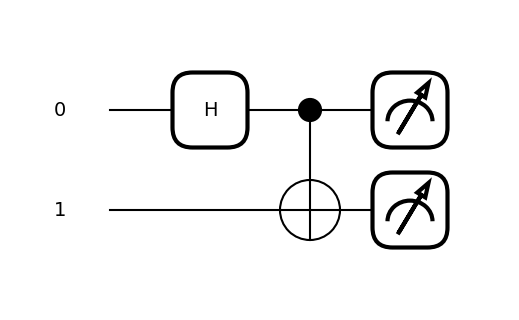

In [4]:
import pennylane as qml
import matplotlib.pyplot as plt

dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def circuito_simple():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.state()

# Esta version es util para cosas tipo terminal o circuitos grandes
print(qml.draw(circuito_simple)())

# Esta version es mucho mas bonita y tiene mas opciones
qml.draw_mpl(circuito_simple)()
plt.show()

**b) Demostrar que los eigenvalores y eigenvectores de $\hat{Z}$ son +1 con |0⟩ y -1 con |1⟩ y con ayuda del teorema de descomposición espectral, demostrar que el valor esperado de Z es la diferencia entre las probabilidades de medir 0 menos las de medir 1.**

Definimos la matriz del operador $\hat{Z}$ y los vectores de la base computacional:
$$\hat{Z} = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}, \quad \ket{0} = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \quad \ket{1} = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

Aplicamos el operador a cada estado:
$$\hat{Z}\ket{0} = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \begin{pmatrix} 1 \\ 0 \end{pmatrix} = (+1)\ket{0}$$

$$\hat{Z}\ket{1} = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} \begin{pmatrix} 0 \\ 1 \end{pmatrix} = \begin{pmatrix} 0 \\ -1 \end{pmatrix} = (-1)\ket{1}$$

Queda demostrado: $\ket{0}$ tiene eigenvalor $+1$ y $\ket{1}$ tiene eigenvalor $-1$.

---

### 2. Valor esperado mediante descomposición espectral

Por el teorema espectral, expresamos $\hat{Z}$ usando sus eigenvalores y proyectores $\ket{v_i}\bra{v_i}$:
$$\hat{Z} = (+1)\ket{0}\bra{0} + (-1)\ket{1}\bra{1} = \ket{0}\bra{0} - \ket{1}\bra{1}$$

Sustituimos en la ecuación del valor esperado para el estado $\ket{\psi} = \alpha\ket{0} + \beta\ket{1}$:
$$\bra{\psi}\hat{Z}\ket{\psi} = \bra{\psi} \left( \ket{0}\bra{0} - \ket{1}\bra{1} \right) \ket{\psi}$$

Por linealidad, distribuimos los términos:
$$\bra{\psi}\hat{Z}\ket{\psi} = \bra{\psi}\ket{0}\bra{0}\ket{\psi} - \bra{\psi}\ket{1}\bra{1}\ket{\psi}$$

Calculamos los productos internos. Sabemos que $\bra{0}\ket{\psi} = \alpha$ y su conjugado $\bra{\psi}\ket{0} = \alpha^*$. Lo mismo aplica para $\beta$:
$$\bra{\psi}\hat{Z}\ket{\psi} = (\alpha^*)(\alpha) - (\beta^*)(\beta)$$
$$\bra{\psi}\hat{Z}\ket{\psi} = |\alpha|^2 - |\beta|^2$$

De acuerdo con la regla de Born, $|\alpha|^2$ es la probabilidad de medir el estado $\ket{0}$, es decir, $P(0)$. De igual forma, $|\beta|^2$ es $P(1)$. Por lo tanto:
$$\langle \hat{Z} \rangle = P(0) - P(1)$$

**c)  Repitan el desarrollo matemático que hicimos para RX en las matrices RY y RZ, y luego generen el circuito en Pennylane, de return coloquen el valor esperado de de la matriz de Paulli Z, grafiquenlo en Matplotlib y argumenten si lo que graficaron se corresponde a lo que el circuito que predijeron iba a dar.**

### Desarrollo Matemático para $R_y$ y $R_z$

Partimos de la identidad para la exponencial de las matrices de Pauli:
$$e^{-i\frac{\theta}{2} \hat{P}} = \cos\left(\frac{\theta}{2}\right)I - i\sin\left(\frac{\theta}{2}\right)\hat{P}$$

#### 1. Rotación en Y ($R_y$)
Sustituimos la matriz $Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$:
$$R_y(\theta) = \cos\left(\frac{\theta}{2}\right) \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} - i\sin\left(\frac{\theta}{2}\right) \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$$
$$R_y(\theta) = \begin{pmatrix} \cos(\frac{\theta}{2}) & -\sin(\frac{\theta}{2}) \\ \sin(\frac{\theta}{2}) & \cos(\frac{\theta}{2}) \end{pmatrix}$$

Aplicamos $R_y(\theta)$ al estado inicial $\ket{0}$:
$$R_y(\theta)\ket{0} = \begin{pmatrix} \cos(\frac{\theta}{2}) & -\sin(\frac{\theta}{2}) \\ \sin(\frac{\theta}{2}) & \cos(\frac{\theta}{2}) \end{pmatrix} \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \begin{pmatrix} \cos(\frac{\theta}{2}) \\ \sin(\frac{\theta}{2}) \end{pmatrix}$$

El valor esperado de $Z$ es la probabilidad de medir 0 menos la de medir 1:
$$\langle Z \rangle_{Ry} = \cos^2\left(\frac{\theta}{2}\right) - \sin^2\left(\frac{\theta}{2}\right) = \cos(\theta)$$

#### 2. Rotación en Z ($R_z$)
Sustituimos la matriz $Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$:
$$R_z(\theta) = \cos\left(\frac{\theta}{2}\right) \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} - i\sin\left(\frac{\theta}{2}\right) \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$
$$R_z(\theta) = \begin{pmatrix} e^{-i\theta/2} & 0 \\ 0 & e^{i\theta/2} \end{pmatrix}$$

Aplicamos $R_z(\theta)$ a $\ket{0}$:
$$R_z(\theta)\ket{0} = \begin{pmatrix} e^{-i\theta/2} & 0 \\ 0 & e^{i\theta/2} \end{pmatrix} \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \begin{pmatrix} e^{-i\theta/2} \\ 0 \end{pmatrix}$$

La probabilidad de medir 0 es la magnitud al cuadrado de la amplitud:
$$P(0) = |e^{-i\theta/2}|^2 = 1, \quad P(1) = 0$$
$$\langle Z \rangle_{Rz} = 1 - 0 = 1$$


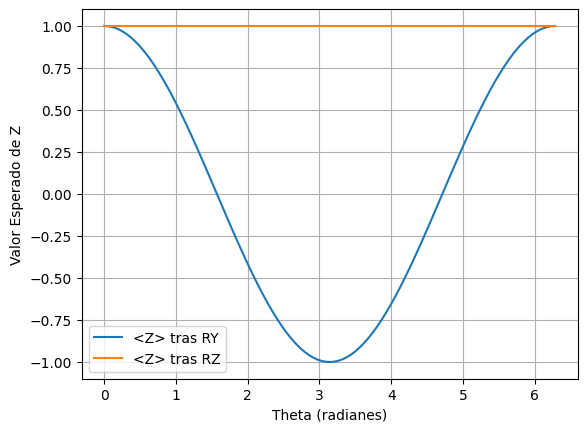

In [5]:
import numpy as np

dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def circuito_ry(theta):
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev)
def circuito_rz(theta):
    qml.RZ(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

thetas = np.linspace(0, 2 * np.pi, 100)
exp_y = [circuito_ry(t) for t in thetas]
exp_z = [circuito_rz(t) for t in thetas]

plt.plot(thetas, exp_y, label="<Z> tras RY")
plt.plot(thetas, exp_z, label="<Z> tras RZ")
plt.xlabel("Theta (radianes)")
plt.ylabel("Valor Esperado de Z")
plt.legend()
plt.grid(True)
plt.show()

Esto concuerda con el calculo, cuando aplicamos $R_z$, iniciando en el $\ket{0}$ y rotar sobre el mismo eje, no cambiamos la latitud y mantenemos la probabilidad igual.

Por el contrario cuando iniciamos en $\ket{0}$ y rotamos hacia abajo *Y*, en $\pi$ llegas al $\ket{1}$

**Contesta las siguientes preguntas usando tu imaginación:**

* **Si podemos fabricar funciones basadas en circuitos cuánticos, ¿podrían existir formas de derivar dichas funciones para obtener utilidad de las mismas?**

Si entendí bien la pregunta, la idea es derivar la función y ver si nos sirve de algo. La verdad no pude pensar en ninguna aplicación por mi cuenta, pero investigando un poco, esta es la idea detrás del *Quantum Machine Learning*.

Como no podemos hacer mediciones directas de ciertos estados sin colapsarlos, entonces no podemos usar directamente *backpropagation* como en redes neuronales clásicas. Sin embargo, podemos utilizar técnicas matemáticas que incluyen derivación para lograr el objetivo.

De esta manera, derivar la función nos permite usar algoritmos de optimización como el descenso de gradiente.

* **¿Qué nuevos horizontes al trabajar con derivadas de funciones generadas por medio de circuitos cuánticos podríamos llegar a alcanzar?**

Como mencioné arriba, lo que encontré está relacionado con *Quantum Machine Learning*. No pude pensar en alguna otra aplicación por mi cuenta. Además de esta área, también existen aplicaciones como las simulaciones de sistemas cuánticos, por ejemplo para minimizar la energía esperada de un sistema.

* **Investiga algún algoritmo que se beneficie de ello y describe brevemente cómo lo hacen, e identifica qué posibles avances para la humanidad podrían traer algoritmos de esta naturaleza**

El algoritmo que encontré fue **VQE** (*Variational Quantum Eigensolver*).

Este es un algoritmo híbrido utilizado para encontrar el estado de mínima energía de un sistema. La idea es utilizar un circuito cuántico con parámetros ajustables, preparar un estado de prueba y medir el hardware cuántico para evaluar la función de costo. Posteriormente, se utiliza la regla de cambio de parámetros (*parameter shift rule*) para calcular el gradiente y, mediante un optimizador clásico, ajustar los parámetros hasta minimizar la energía.


### Referencias  

- Xanadu. (s.f.). Quantum gradients. PennyLane. https://pennylane.ai/qml/glossary/quantum_gradient/

- Xanadu. (s.f.). The parameter-shift rule. PennyLane. https://pennylane.ai/qml/glossary/parameter_shift_rule/

- IBM Quantum. (s.f.). Variational Quantum Eigensolver (VQE). Qiskit Textbook. https://learning.quantum.ibm.com/course/variational-algorithm-design/variational-quantum-eigensolver